In [1]:
#Baseline Algorithms, Function Implementations
from Single_ag_Environment import SingleSatelliteEnv#Import Environment
from gymnasium.utils.env_checker import check_env
import traceback
import numpy as np
print(type(SingleSatelliteEnv))
# This will catch many common issues
env = SingleSatelliteEnv(render_mode="None")#Set variable as imported environment with specific render mode (dummy input)
try:
    check_env(env)#Check the environment to be safe
    print("Environment passes all checks!")
except Exception as e:
    print("Environment has issues:")
    traceback.print_exc()

<class 'type'>
0.85
0.3545947
0.7
0.76761246
0.7
0.73805195
0.7
0.38320324
0.7
0.7110631
0.7
0.023169886
0.7
0.95830894
0.7
0.7583671
0.7
0.26147363
0.7
0.4517113
0.7
Contact Delivered Data
5
Environment passes all checks!


/home/ethan/Documents/Research/Single_Agent_EO_Project/SingAgvenv/lib/python3.10/site-packages/gymnasium/utils/env_checker.py:434: UserWarning: WARN: Not able to test alternative render modes due to the environment not having a spec. Try instantiating the environment through `gymnasium.make`
  logger.warn(


In [2]:
#Here we implement Baseline CGR as a function that can be called 
def BaselineCGR(env):
    
    init_observation,init_info=env.reset()#Reset the environment
    #print(init_observation)
    delivery_ratio_metric=None#Define the delivery ratio metric
    contact_energy_efficiency=None#Define the energy efficiency metric
    total_reward=0#Initialize the total reward metric
    done=False#Set the while loop conditional to False
    while not done:
        action = 1#Always choose action 1
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated#Check if the episode is over
        total_reward += reward#update the rewards for the episode
    #Next we need to extract final info from the episode
    initial_data_volume=info["Initial Data"]#Extract the initial data volume from info
    print("CGR")
    print("Initial Data Volume")
    print(initial_data_volume)
    delivered_packets=info["Delivered Data"]#Get the number of delivered packet from info
    print(delivered_packets)
    number_of_contacts=info["Number of Contacts"]#Get the numbre of contacts used
    excess_energy_expended=info["Energy Expended"]#Get the amount of excess enegy expended
    if((initial_data_volume*100)<delivered_packets):
        print("Delivery ratio error")
    return total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended#Return key metrics
    env.close()

    

In [9]:

def AdaptiveSorting(env):
    initial_observation,initial_information=env.reset()
    print(initial_observation)
    initial_data_volume=initial_observation[10]*100
    contacts_available=initial_observation[0:10]
    sorted_matrix=np.zeros([10,2])
    current_contact_iterator=0
    total_reward=0
  
    
    #Next we must calculate the initial allocation of contacts
    j=0
    for i in contacts_available:
        sorted_matrix[j,0]=i
        sorted_matrix[j,1]=j
        j=j+1
    sorted_matrix=sorted_matrix[sorted_matrix[:, 0].argsort()]
    #print("Initial Sorted Matrix")
    #print(sorted_matrix)
    remaining_data=initial_data_volume
    #print("Initial Data to send")
    #print(remaining_data)
    decision_matrix=np.zeros([10,2])
    
    j=0
    for i in range(0,len(decision_matrix)):
        if (remaining_data>0):
            if sorted_matrix[i,0]<1:
                remaining_data=remaining_data-(10-sorted_matrix[i,0]*10)
                
                decision_matrix[i,0]=1
                decision_matrix[i,1]=sorted_matrix[i,1]
            else:
                decision_matrix[i,0]=0
                decision_matrix[i,1]=sorted_matrix[i,1]
        else:
            decision_matrix[i,0]=0
            decision_matrix[i,1]=sorted_matrix[i,1]
    #Next we must reorder the decision matrix
    

    #print("Decision Matrix")
    #print(decision_matrix)
    sorted_decisions=decision_matrix[decision_matrix[:,1].argsort()]
    #print("Sorted Decisions")
    #print(sorted_decisions)
    action_decision_matrix=np.zeros(10)
    for i in range(0,len(sorted_decisions)):
        action_decision_matrix[i]=sorted_decisions[i,0]
    #print("Actual set of Actions")
    #print(action_decision_matrix)
    obs=initial_observation
    i=0
    done=False
    while not done:
        if action_decision_matrix[i]==0:
            #We don't use this contact
            action=0
            next_obs, reward, terminated, truncated, info = env.step(action)
            print("Action")
            print(action)
            total_reward+=reward
        else:
            #We use the contact
            
            action=1
            #print(action)
            next_obs, reward, terminated, truncated, info = env.step(action)
            total_reward+=reward
            #Next we need to determine if we successfully delivered any packets
            current_delivered=1-next_obs[10]
            print("Current_Delivered")
            print(current_delivered)
            previous_delivered=1-obs[10]
            #print(previous_delivered)
            if (current_delivered<previous_delivered):
                #We need to recalculate the decision matrix
                remaining_data=current_delivered*100
                aux_sorting_matrix=np.zeros([10,2])
                for j in range(0,10):
                    aux_sorting_matrix[j,0]=contacts_available[j]
                    aux_sorting_matrix[j,1]=j
                for j in range(0,i+1):
                    aux_sorting_matrix[j,0]=1
                #print("Auxilliary Sorting Matrix")
                #print(aux_sorting_matrix)
                aux_sorting_matrix=aux_sorting_matrix[aux_sorting_matrix[:, 0].argsort()]
                #print("Auxilliary Sorting Matrix")
                #print(aux_sorting_matrix)
                decision_matrix=np.zeros([10,2])
                k=0
                for j in range(0,len(decision_matrix)):
                    if remaining_data>0:
                        if aux_sorting_matrix[j,0]<1:
                            remaining_data=remaining_data-(10-aux_sorting_matrix[j,0]*10)
                            decision_matrix[j,0]=1
                            decision_matrix[j,1]=aux_sorting_matrix[j,1]
                        else:
                            decision_matrix[j,0]=0
                            decision_matrix[j,1]=aux_sorting_matrix[j,1]
                    else:
                        decision_matrix[j,0]=0
                        decision_matrix[j,1]=aux_sorting_matrix[j,1]

                aux_sorting_decisions=decision_matrix[decision_matrix[:,1].argsort()]
                action_decision_matrix=np.zeros(10)
                for k in range(0,len(aux_sorting_decisions)):
                    action_decision_matrix[k]=aux_sorting_decisions[k,0]
                #print("New Decision Matrix")
                #print(action_decision_matrix)
        i+=1
        obs=next_obs
        done = terminated or truncated
    #Next we need to graph and log the results of the heuristic algorithm
    initial_data_volume=info["Initial Data"]
    print("Sorting Algo")
    print("Initial Data Volume")
    print(initial_data_volume)
    delivered_packets=info["Delivered Data"]
    print(delivered_packets)
    number_of_contacts=info["Number of Contacts"]
    excess_energy_expended=info["Energy Expended"]
    if((initial_data_volume*100)<delivered_packets):
        print("Delivery ratio error")
    #print("Delivered Packets")
    #print(delivered_packets)
    #print("Number of Contacts")
    #print(number_of_contacts)
    #print("Initial Data Volume")
    #print(initial_data_volume)
    return total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended
    env.close()


In [10]:
#Basic debugging tests for sorting algorithm
env.reset(seed=1)
total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended=AdaptiveSorting(env)
print(total_reward)
env.reset(seed=1)
total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended=BaselineCGR(env)
print(total_reward)

[0.5  0.3  0.8  0.3  0.5  0.1  0.4  0.2  0.3  0.8  0.76 0.  ]
0.76
0.28040877
0.5
0.485191
0.5
0.9807372
0.5
0.96165717
0.5
0.7247899
0.5
0.54122686
0.5
0.2768912
0.5
0.16065201
0.5
0.9699254
0.5
0.5160686
0.5
Contact Delivered Data
6
Current_Delivered
0.3
0.7
0.11586561
0.3
0.62348974
0.3
0.7766831
0.3
0.6130033
0.3
0.9172977
0.3
0.039592877
0.3
0.52858925
0.3
0.4593359
0.3
0.06234958
0.3
0.64132816
0.3
Contact Delivered Data
7
Current_Delivered
0.37
0.63
0.8526328
0.8
0.59294105
0.8
0.26009744
0.8
0.83988154
0.8
0.50949585
0.8
0.5108889
0.8
0.7530302
0.8
0.14792204
0.8
0.81962675
0.8
0.6832869
0.8
Contact Delivered Data
3
Current_Delivered
0.39999998
0.6
0.7870969
0.3
0.19161625
0.3
0.8023642
0.3
0.19132392
0.3
0.08155262
0.3
0.855227
0.3
0.8612835
0.3
0.8765371
0.3
0.47190973
0.3
0.2740484
0.3
Contact Delivered Data
6
Current_Delivered
0.45999998
0.54
0.0070918286
0.5
0.6457209
0.5
0.71990937
0.5
0.8355692
0.5
0.28187782
0.5
0.21521817
0.5
0.6393314
0.5
0.80505484
0.5
0.96367085
0.5

0.98
0.3737309
0.4
0.7065091
0.4
0.061408103
0.4
0.23580973
0.4
0.24576245
0.4
0.44861054
0.4
0.33167264
0.4
0.7717461
0.4
0.4730928
0.4
0.7804164
0.4
Contact Delivered Data
5
1
0.93
0.12486298
0.3
0.57882965
0.3
0.7067573
0.3
0.6835449
0.3
0.03673201
0.3
0.1768846
0.3
0.609046
0.3
0.2691984
0.3
0.4514802
0.3
0.8942798
0.3
Contact Delivered Data
6
1
0.87
0.86253494
0.1
0.0035814245
0.1
0.51404524
0.1
0.9294835
0.1
0.34964114
0.1
0.47224265
0.1
0.37014186
0.1
0.8048341
0.1
0.4395977
0.1
0.9046282
0.1
Contact Delivered Data
9
1
0.78
0.19096543
0.1
0.41442844
0.1
0.41894457
0.1
0.6320369
0.1
0.49932125
0.1
0.25468728
0.1
0.8571496
0.1
0.5119556
0.1
0.22664705
0.1
0.86113083
0.1
Contact Delivered Data
10
1
0.68
0.98779696
1.0
0.026307069
1.0
0.19926527
1.0
0.5564561
1.0
0.37511742
1.0
0.87074786
1.0
0.42214158
1.0
0.50418276
1.0
0.4821766
1.0
0.86910903
1.0
Contact Delivered Data
0
1
0.68
0.43782204
0.6
0.5855746
0.6
0.083770536
0.6
0.75778383
0.6
0.07705472
0.6
0.01984523
0.6
0.6448006
0.

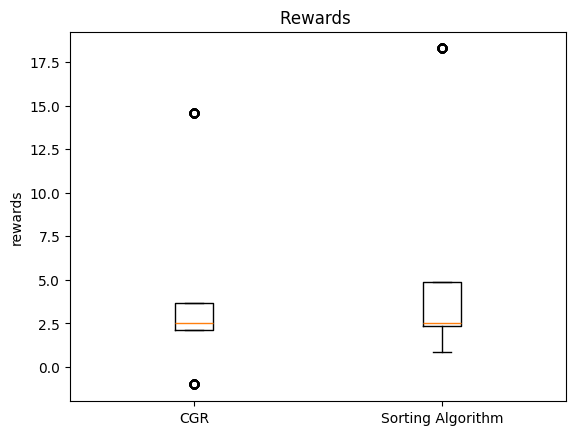

Mean Values
CGR delivery ratio
0.6770130813121795
Sorting delivery ratio
0.6795492708683014


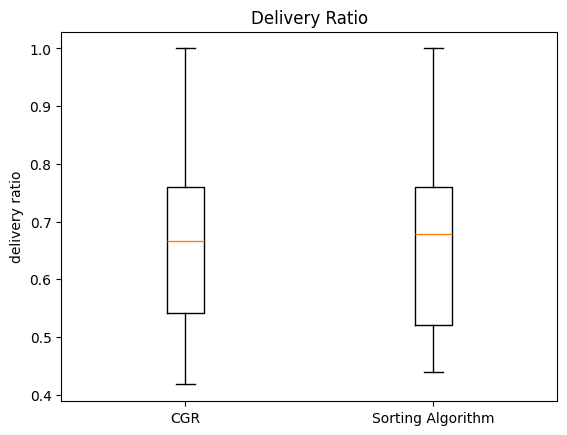

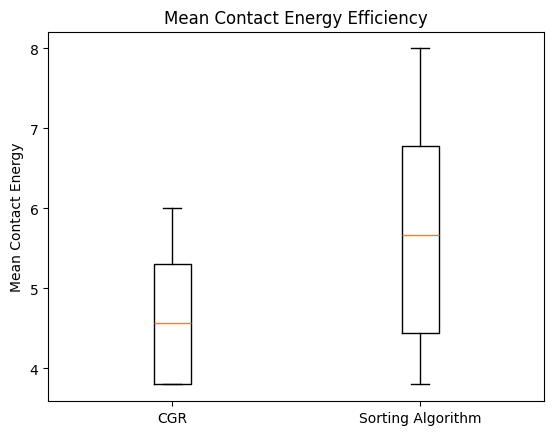

In [8]:
#Next we need to test these baseline algorithms and produce delivery, reward and contact energy efficiency
#graphs
Number_of_Episodes=100
seeds=[50,51,52,53,54]
CGR_reward_vector=np.zeros([len(seeds)*Number_of_Episodes,])
CGR_delivery_ratio_vector=np.zeros([len(seeds)*Number_of_Episodes,])
CGR_mean_contact_energy_efficiency_vector=np.zeros([len(seeds)*Number_of_Episodes,])
vector_index=0
for h in range(0,Number_of_Episodes):
        for b in seeds:
            env.reset(b)
            total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended=BaselineCGR(env)
          
            CGR_reward_vector[vector_index]=total_reward
            CGR_delivery_ratio_vector[vector_index]=delivered_packets/(initial_data_volume*100)
            CGR_mean_contact_energy_efficiency_vector[vector_index]=delivered_packets/number_of_contacts
            vector_index+=1
#Next we must make box plots these results



#Adaptive sorting Algorithm

Sorting_reward_vector=np.zeros([len(seeds)*Number_of_Episodes,])
Sorting_delivery_ratio_vector=np.zeros([len(seeds)*Number_of_Episodes,])
Sorting_mean_contact_energy_efficiency_vector=np.zeros([len(seeds)*Number_of_Episodes,])
vector_index=0
for h in range(0,Number_of_Episodes):
        for b in seeds:
            env.reset(b)
            total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended=AdaptiveSorting(env)
            Sorting_reward_vector[vector_index]=total_reward
            
            Sorting_delivery_ratio_vector[vector_index]=delivered_packets/(initial_data_volume*100)
            print("Delivered Packets")
            print(delivered_packets)
            print("Initial Data Volume")
            print(initial_data_volume*100)
            print("Number of Contacts")
            print(number_of_contacts)
            Sorting_mean_contact_energy_efficiency_vector[vector_index]=delivered_packets/number_of_contacts
            vector_index+=1
print("Sorting Delivery Ratio")
print(Sorting_delivery_ratio_vector)
print("CGR Delivery Ratio")
print(CGR_delivery_ratio_vector)
import matplotlib.pyplot as plt
#Reward Plot
#print("Sorting Reward")
#print(np.mean(Sorting_reward_vector))
#print(Sorting_reward_vector)
#print(CGR_reward_vector)
#print("CGR Reward")
print(np.mean(CGR_reward_vector))
plt.boxplot([CGR_reward_vector, Sorting_reward_vector], tick_labels=['CGR', 'Sorting Algorithm'])

plt.title("Rewards ")
plt.ylabel("rewards")
plt.show()
print("Mean Values")
print("CGR delivery ratio")
print(np.mean(CGR_delivery_ratio_vector))
print("Sorting delivery ratio")
print(np.mean(Sorting_delivery_ratio_vector))
#Delivery Ratio Plot
plt.boxplot([CGR_delivery_ratio_vector, Sorting_delivery_ratio_vector], tick_labels=['CGR', 'Sorting Algorithm'])

plt.title("Delivery Ratio")
plt.ylabel("delivery ratio")
plt.show()
#Contact Energy Efficiency Plot
plt.boxplot([CGR_mean_contact_energy_efficiency_vector, Sorting_mean_contact_energy_efficiency_vector], tick_labels=['CGR', 'Sorting Algorithm'])

plt.title("Mean Contact Energy Efficiency")
plt.ylabel("Mean Contact Energy")
plt.show()